## Travelling salesman problem

The Travelling Salesman Problem (TSP) is the challenge of finding the shortest (yet most efficient) route for a person to take given a list of specific destinations. It is a well-known algorithmic problem in the fields of computer science and operations research.

The most direct solution to the TSP problem is to try all permutations (ordered combinations) and see which one is the shortest (using brute-force search). The running time for this approach scales as $\mathcal{O}[N!]$, the factorial of the number of cities, so this solution becomes impractical even for only 20 cities. We will nevertheless try to implement the brute-force method.

Let's generate a list of cities and find distances between them:

In [1]:
import numpy as np

number_of_cities = 10

X = np.random.rand(number_of_cities, 2) 
dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)
city_distances = np.sqrt(dist_sq)
print(np.round(city_distances,3))

[[0.    0.557 0.573 0.468 0.477 0.623 0.449 0.277 0.121 0.491]
 [0.557 0.    1.123 0.83  0.952 0.948 1.004 0.659 0.652 1.008]
 [0.573 1.123 0.    0.523 0.525 0.602 0.134 0.536 0.471 0.413]
 [0.468 0.83  0.523 0.    0.812 0.155 0.492 0.199 0.37  0.756]
 [0.477 0.952 0.525 0.812 0.    0.953 0.418 0.681 0.487 0.121]
 [0.623 0.948 0.602 0.155 0.953 0.    0.6   0.351 0.524 0.888]
 [0.449 1.004 0.134 0.492 0.418 0.6   0.    0.456 0.355 0.319]
 [0.277 0.659 0.536 0.199 0.681 0.351 0.456 0.    0.2   0.651]
 [0.121 0.652 0.471 0.37  0.487 0.524 0.355 0.2   0.    0.471]
 [0.491 1.008 0.413 0.756 0.121 0.888 0.319 0.651 0.471 0.   ]]


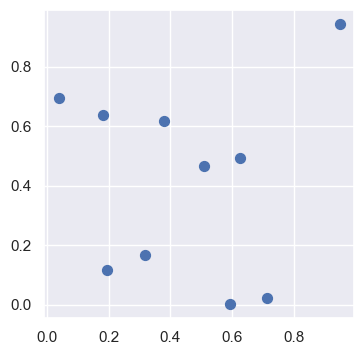

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set() # Plot styling

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], s=50);

We will use the ``permutations`` function from the [itertools](https://docs.python.org/3/library/itertools.html) module to generate a list of all posible routes:

In [3]:
from itertools import permutations
routes = np.array(list(permutations(range(city_distances.shape[0]))))
routes.shape # there are N! routes of length N

(3628800, 10)

Next, we need a function that computes the length of a given route. We use a fancy indexing to select distances from neihbouring cities in the route, i.e. for a route (0,1,3,2) we need to select and sum the distances (0,1), (1,3), (3,2) and (2,0). This is equivalent to suming distances (0,2), (1,0), (3,1) and (2,3) since the distances are symmatric.

In [4]:
def route_len(distances, route):
    return np.sum(distances[route,route[np.arange(len(route))-1]])

Let's give it a test:

In [5]:
print(routes[0])
print(route_len(city_distances,routes[0]))

[0 1 2 3 4 5 6 7 8 9]
6.184669685030549


It remains to loop over all the routes and use ``argmin`` to fince the shortest route.

In [6]:
route_distances = np.zeros(routes.shape[0])
for i in range(route_distances.shape[0]):
    route_distances[i] = route_len(city_distances, routes[i])

The shortest route and its distance are:

In [7]:
j_min_route = np.argmin(route_distances)
print(routes[j_min_route])
min(route_distances)

[0 1 7 3 5 2 6 9 4 8]


3.353560762020105

To visualise this route we need to close it into a loop:

In [8]:
min_route_loop = np.append(routes[j_min_route],routes[j_min_route][0])
print(np.round(X[min_route_loop],3))

[[0.627 0.492]
 [0.952 0.944]
 [0.379 0.617]
 [0.181 0.637]
 [0.037 0.695]
 [0.195 0.114]
 [0.319 0.165]
 [0.593 0.002]
 [0.712 0.023]
 [0.509 0.465]
 [0.627 0.492]]


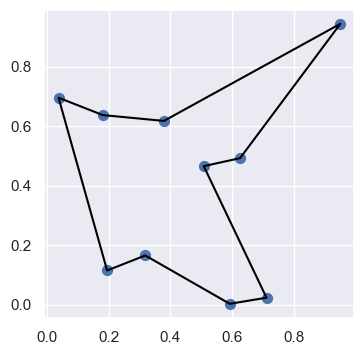

In [9]:
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], s=50) 
plt.plot(X[min_route_loop][:,0], X[min_route_loop][:,1], color='black');

---